In [8]:
from pathlib import Path
import xml.etree.ElementTree as ET
import shutil
import random
import yaml

import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as patches

In [9]:
CURRENT_DIR = Path.cwd()

if CURRENT_DIR.name == "notebooks":
    PROJECT_ROOT = CURRENT_DIR.parent
else:
    PROJECT_ROOT = CURRENT_DIR

RAW_DATA_DIR = PROJECT_ROOT / "data" / "raw"
IMAGES_DIR = RAW_DATA_DIR / "images"
ANNOTATIONS_DIR = RAW_DATA_DIR / "annotations"

YOLO_FORMAT_DIR = PROJECT_ROOT / "data" / "yolo_format"
YOLO_IMAGES_DIR = YOLO_FORMAT_DIR / "images"
YOLO_LABELS_DIR = YOLO_FORMAT_DIR / "labels"

SPLITS_DIR = PROJECT_ROOT / "data" / "splits"

print("Project root:", PROJECT_ROOT)
print("Images directory:", IMAGES_DIR)
print("Annotations directory:", ANNOTATIONS_DIR)

Project root: e:\yolo_pothole
Images directory: e:\yolo_pothole\data\raw\images
Annotations directory: e:\yolo_pothole\data\raw\annotations


In [10]:
YOLO_IMAGES_DIR.mkdir(parents=True, exist_ok=True)
YOLO_LABELS_DIR.mkdir(parents=True, exist_ok=True)

print("YOLO image output:", YOLO_IMAGES_DIR)
print("YOLO label output:", YOLO_LABELS_DIR)

YOLO image output: e:\yolo_pothole\data\yolo_format\images
YOLO label output: e:\yolo_pothole\data\yolo_format\labels


In [11]:
CLASS_MAP = {
    "pothole": 0
}

CLASS_MAP

{'pothole': 0}

The dataset contains only one object class: `pothole`. Therefore, all YOLO labels will use class ID `0`.

In [12]:
def parse_voc_annotation(xml_path):
    tree = ET.parse(xml_path)
    root = tree.getroot()

    filename = root.find("filename").text
    width = int(root.find("size/width").text)
    height = int(root.find("size/height").text)

    objects = []

    for obj in root.findall("object"):
        class_name = obj.find("name").text.strip().lower()
        bndbox = obj.find("bndbox")

        xmin = int(float(bndbox.find("xmin").text))
        ymin = int(float(bndbox.find("ymin").text))
        xmax = int(float(bndbox.find("xmax").text))
        ymax = int(float(bndbox.find("ymax").text))

        objects.append({
            "class_name": class_name,
            "bbox": [xmin, ymin, xmax, ymax]
        })

    return {
        "filename": filename,
        "width": width,
        "height": height,
        "objects": objects
    }

The parser extracts the image filename, image dimensions, object class, and bounding box coordinates from each VOC XML file. These values are needed before converting the annotations into YOLO format.

In [13]:
def clean_bbox(bbox, img_width, img_height):
    xmin, ymin, xmax, ymax = bbox

    original_bbox = [xmin, ymin, xmax, ymax]

    # Clip coordinates to image boundary
    xmin = max(0, min(xmin, img_width))
    ymin = max(0, min(ymin, img_height))
    xmax = max(0, min(xmax, img_width))
    ymax = max(0, min(ymax, img_height))

    cleaned_bbox = [xmin, ymin, xmax, ymax]

    was_clipped = original_bbox != cleaned_bbox

    # Remove zero-area or invalid boxes
    if xmax <= xmin or ymax <= ymin:
        return None, was_clipped

    return cleaned_bbox, was_clipped

def voc_to_yolo(bbox, img_width, img_height):
    xmin, ymin, xmax, ymax = bbox

    box_width = xmax - xmin
    box_height = ymax - ymin

    x_center = xmin + box_width / 2
    y_center = ymin + box_height / 2

    x_center /= img_width
    y_center /= img_height
    box_width /= img_width
    box_height /= img_height

    return x_center, y_center, box_width, box_height

In [14]:
image_files = list(IMAGES_DIR.glob("*.jpg")) + list(IMAGES_DIR.glob("*.jpeg")) + list(IMAGES_DIR.glob("*.png"))
xml_files = sorted(list(ANNOTATIONS_DIR.glob("*.xml")))

image_lookup = {img.stem: img for img in image_files}

converted_images = 0
converted_boxes = 0
removed_boxes = 0
clipped_boxes = 0
missing_images = []

for xml_path in xml_files:
    annotation = parse_voc_annotation(xml_path)

    xml_stem = xml_path.stem

    if xml_stem not in image_lookup:
        missing_images.append(xml_path.name)
        continue

    image_path = image_lookup[xml_stem]
    output_image_path = YOLO_IMAGES_DIR / image_path.name
    output_label_path = YOLO_LABELS_DIR / f"{image_path.stem}.txt"

    yolo_lines = []

    for obj in annotation["objects"]:
        class_name = obj["class_name"]

        if class_name not in CLASS_MAP:
            continue

        cleaned_bbox, was_clipped = clean_bbox(
            obj["bbox"],
            annotation["width"],
            annotation["height"]
        )

        if was_clipped:
            clipped_boxes += 1

        if cleaned_bbox is None:
            removed_boxes += 1
            continue

        x_center, y_center, box_width, box_height = voc_to_yolo(
            cleaned_bbox,
            annotation["width"],
            annotation["height"]
        )

        class_id = CLASS_MAP[class_name]

        yolo_line = f"{class_id} {x_center:.6f} {y_center:.6f} {box_width:.6f} {box_height:.6f}"
        yolo_lines.append(yolo_line)

        converted_boxes += 1

    # Copy image
    shutil.copy2(image_path, output_image_path)

    # Write YOLO label file
    with open(output_label_path, "w") as f:
        f.write("\n".join(yolo_lines))

    converted_images += 1

print("Converted images:", converted_images)
print("Converted boxes:", converted_boxes)
print("Removed invalid boxes:", removed_boxes)
print("Clipped boxes:", clipped_boxes)
print("Missing images:", len(missing_images))

Converted images: 665
Converted boxes: 1739
Removed invalid boxes: 1
Clipped boxes: 1
Missing images: 0


In [15]:
sample_label = sorted(YOLO_LABELS_DIR.glob("*.txt"))[0]

print("Sample label file:", sample_label.name)

with open(sample_label, "r") as f:
    print(f.read())

Sample label file: potholes0.txt
0 0.382222 0.825000 0.137778 0.096667
0 0.487778 0.758333 0.082222 0.056667
0 0.260000 0.613333 0.133333 0.080000
0 0.436667 0.593333 0.068889 0.046667
0 0.564444 0.600000 0.080000 0.033333
0 0.693333 0.593333 0.048889 0.033333
0 0.572222 0.576667 0.117778 0.026667
0 0.431111 0.496667 0.084444 0.046667
0 0.191111 0.481667 0.035556 0.023333
0 0.305556 0.503333 0.064444 0.040000
0 0.357778 0.445000 0.031111 0.023333
0 0.808889 0.770000 0.195556 0.100000


In [16]:
def yolo_to_xyxy(yolo_box, img_width, img_height):
    x_center, y_center, box_width, box_height = yolo_box

    x_center *= img_width
    y_center *= img_height
    box_width *= img_width
    box_height *= img_height

    xmin = x_center - box_width / 2
    ymin = y_center - box_height / 2
    xmax = x_center + box_width / 2
    ymax = y_center + box_height / 2

    return xmin, ymin, xmax, ymax


def draw_yolo_labels(image_path, label_path):
    image = cv2.imread(str(image_path))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    img_height, img_width = image.shape[:2]

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.imshow(image)

    if label_path.exists():
        with open(label_path, "r") as f:
            lines = f.readlines()

        for line in lines:
            values = line.strip().split()

            if len(values) != 5:
                continue

            class_id = int(values[0])
            x_center, y_center, box_width, box_height = map(float, values[1:])

            xmin, ymin, xmax, ymax = yolo_to_xyxy(
                [x_center, y_center, box_width, box_height],
                img_width,
                img_height
            )

            rect = patches.Rectangle(
                (xmin, ymin),
                xmax - xmin,
                ymax - ymin,
                linewidth=2,
                edgecolor="red",
                facecolor="none"
            )

            ax.add_patch(rect)
            ax.text(
                xmin,
                max(ymin - 5, 0),
                f"class {class_id}",
                color="red",
                fontsize=10
            )

    ax.set_title(image_path.name)
    ax.axis("off")
    plt.show()

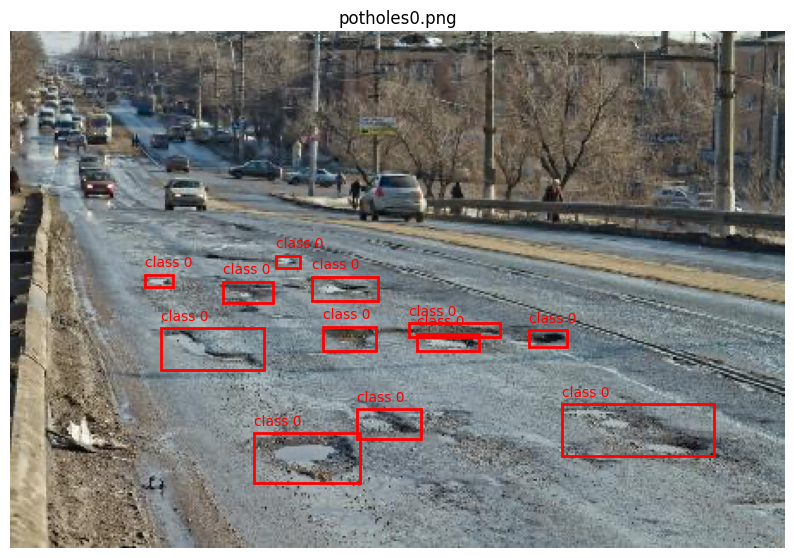

In [17]:
sample_image = sorted(YOLO_IMAGES_DIR.glob("*"))[0]
sample_label = YOLO_LABELS_DIR / f"{sample_image.stem}.txt"

draw_yolo_labels(sample_image, sample_label)

The converted YOLO labels are visualized by converting them back into pixel-based corner coordinates. This verification step is important because it confirms that the conversion from VOC to YOLO format preserved the correct object locations.

In [18]:
for split in ["train", "val", "test"]:
    (SPLITS_DIR / "images" / split).mkdir(parents=True, exist_ok=True)
    (SPLITS_DIR / "labels" / split).mkdir(parents=True, exist_ok=True)

print("Split folders created.")

Split folders created.


In [19]:
random.seed(42)

all_images = sorted(list(YOLO_IMAGES_DIR.glob("*.jpg")) + 
                    list(YOLO_IMAGES_DIR.glob("*.jpeg")) + 
                    list(YOLO_IMAGES_DIR.glob("*.png")))

random.shuffle(all_images)

n_total = len(all_images)
n_train = int(n_total * 0.8)
n_val = int(n_total * 0.1)

train_images = all_images[:n_train]
val_images = all_images[n_train:n_train + n_val]
test_images = all_images[n_train + n_val:]

print("Total images:", n_total)
print("Train images:", len(train_images))
print("Val images:", len(val_images))
print("Test images:", len(test_images))

Total images: 665
Train images: 532
Val images: 66
Test images: 67


The dataset is split into training, validation, and test sets using an 80/10/10 ratio. The training set is used to fit the model, the validation set is used during training to monitor generalization, and the test set is held out for final evaluation.

In [20]:
def copy_split_files(image_list, split_name):
    for image_path in image_list:
        label_path = YOLO_LABELS_DIR / f"{image_path.stem}.txt"

        target_image_path = SPLITS_DIR / "images" / split_name / image_path.name
        target_label_path = SPLITS_DIR / "labels" / split_name / label_path.name

        shutil.copy2(image_path, target_image_path)

        if label_path.exists():
            shutil.copy2(label_path, target_label_path)
        else:
            # Create empty label file if no objects exist
            target_label_path.touch()


copy_split_files(train_images, "train")
copy_split_files(val_images, "val")
copy_split_files(test_images, "test")

print("Files copied into train/val/test split folders.")

Files copied into train/val/test split folders.


In [21]:
for split in ["train", "val", "test"]:
    image_count = len(list((SPLITS_DIR / "images" / split).glob("*")))
    label_count = len(list((SPLITS_DIR / "labels" / split).glob("*.txt")))

    print(f"{split}: {image_count} images, {label_count} labels")

train: 532 images, 532 labels
val: 66 images, 66 labels
test: 67 images, 67 labels


In [22]:
dataset_yaml = {
    "path": str(SPLITS_DIR),
    "train": "images/train",
    "val": "images/val",
    "test": "images/test",
    "names": {
        0: "pothole"
    }
}

DATASET_YAML_PATH = PROJECT_ROOT / "src" / "yolo_pipeline" / "dataset.yaml"
DATASET_YAML_PATH.parent.mkdir(parents=True, exist_ok=True)

with open(DATASET_YAML_PATH, "w") as f:
    yaml.dump(dataset_yaml, f, sort_keys=False)

print("Saved dataset YAML to:", DATASET_YAML_PATH)

Saved dataset YAML to: e:\yolo_pothole\src\yolo_pipeline\dataset.yaml


In [23]:
with open(DATASET_YAML_PATH, "r") as f:
    print(f.read())

path: e:\yolo_pothole\data\splits
train: images/train
val: images/val
test: images/test
names:
  0: pothole



## Summary

This notebook converted the pothole dataset from PASCAL VOC XML format into YOLO annotation format.

The conversion process included:
- parsing VOC XML files
- cleaning invalid bounding boxes
- clipping boxes that slightly exceeded image boundaries
- removing zero-area boxes
- converting box coordinates into normalized YOLO format
- creating YOLO `.txt` label files
- splitting the dataset into train, validation, and test sets
- creating a `dataset.yaml` configuration file for YOLO training

After conversion, the dataset is now ready for YOLO model training.